## Importing libraries:

In [2]:
import ast
import pandas as pd 
import seaborn as sns 
from datasets import load_dataset
import matplotlib.pyplot as plt 

## Loading data:


In [5]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


## Data cleanup:

In [ ]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Filter for jobs in Europe:

In [9]:
# Some countries may have different name variants as 'Czechia'/'Czech Republic'
european_countries = [
    'Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 
    'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Czech Republic', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 
    'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 
    'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 
    'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 
    'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 
    'Ukraine', 'United Kingdom', 'UK', 'Vatican City'
]

# Condition to meet
df_europe = df[df['job_country'].isin(european_countries)]

## Location of the jobs:

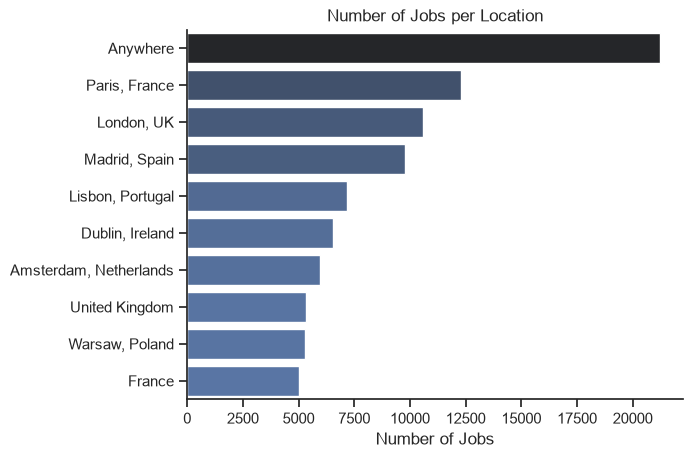

In [13]:
df_plot = df_europe['job_location'].value_counts().head(10).reset_index()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Number of Jobs per Location')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Job opportunities:

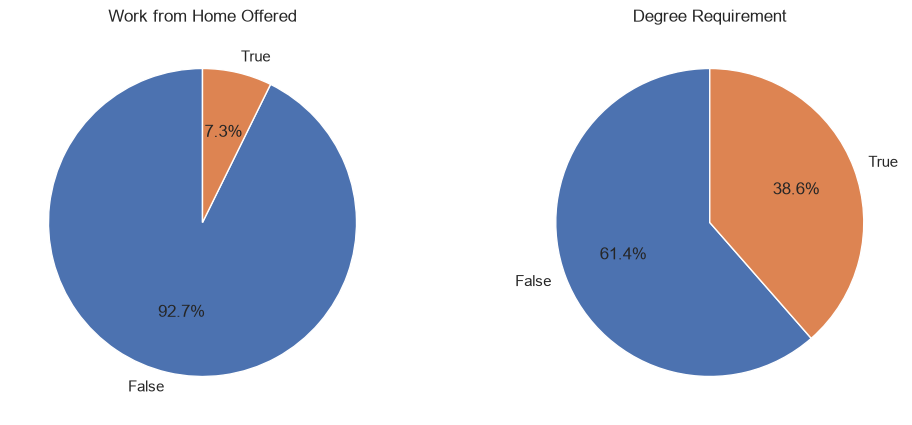

In [16]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    
}

fig, ax = plt.subplots(1, 2)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_europe[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

## Companies with the most job offers:

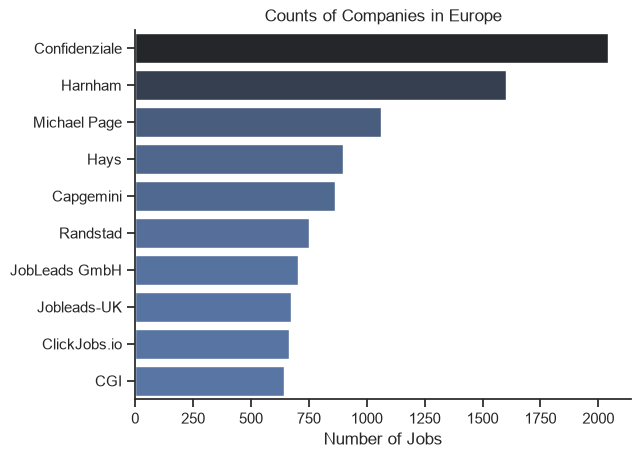

In [17]:
df_plot = df_europe['company_name'].value_counts().head(10).reset_index()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Counts of Companies in Europe')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()